# EDA — Competencia 01

Análisis Exploratorio de Datos. Suma los períodos no analizados (202103–202108).

In [13]:
import os
import sys
sys.path.insert(0, os.path.dirname(os.path.abspath("")))  # para importar fernando/semillas.py
from semillas import SEMILLA

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

# Mismo criterio que z101: el notebook corre igual en Colab y en local
EN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")

if EN_COLAB:
    dataset_path = "/content/drive/MyDrive/DMEyF/2026/notebooks/data/"
else:
    raiz = os.getcwd()
    for _ in range(4):
        if os.path.isdir(os.path.join(raiz, "data")) or os.path.isdir(os.path.join(raiz, ".git")):
            break
        raiz = os.path.dirname(raiz)
    dataset_path = os.path.join(raiz, "data") + os.sep

dataset_file = "competencia_01.csv"
csv = os.path.join(dataset_path, dataset_file)
print(f"dataset: {csv}")

ganancia_acierto = 1_072_500
costo_estimulo = 27_500
umbral_negocio = costo_estimulo / (ganancia_acierto + costo_estimulo)
print(f"umbral de negocio: {umbral_negocio:.4f}")

dataset: c:\Users\usuario\Documents\DMEyF2026\dmeyf2026\data\competencia_01.csv
umbral de negocio: 0.0250


In [4]:
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE VIEW c01 AS SELECT * FROM read_csv_auto('{csv}')")


def q(sql: str) -> pd.DataFrame:
    """Ejecuta SQL sobre la vista c01 y devuelve un DataFrame."""
    return con.execute(sql).df()


cols = [r[0] for r in con.execute("DESCRIBE c01").fetchall()]
feat = [c for c in cols if c not in ("numero_de_cliente", "foto_mes", "clase_ternaria")]
print(f"columnas: {len(cols)} | features: {len(feat)}")

columnas: 155 | features: 152


In [ ]:
## 1. Estructura de faltantes por mes

Si el % de faltantes de una variable saltara de un mes a otro, cualquier
conclusión sobre ella sería frágil.

In [5]:
expr = ", ".join(
    f'round(100.0*avg(CASE WHEN "{c}" IS NULL THEN 1 ELSE 0 END), 2) AS "{c}"' for c in feat
)
nulos = q(f"SELECT foto_mes, {expr} FROM c01 GROUP BY foto_mes ORDER BY foto_mes")

m = nulos.set_index("foto_mes").T
m.columns = [str(c) for c in m.columns]
amplitud = m.max(axis=1) - m.min(axis=1)

nunca = m[(m == 0).all(axis=1)]
estables = m[((m > 0).all(axis=1)) & (amplitud < 0.5)]
varian = m[amplitud >= 0.5]

print(f"sin faltantes en ningún mes      : {len(nunca)}")
print(f"faltantes estables entre meses   : {len(estables)}")
print(f"faltantes que varían entre meses : {len(varian)}")

varian.assign(amplitud=amplitud).sort_values("amplitud", ascending=False).round(1)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

sin faltantes en ningún mes      : 106
faltantes estables entre meses   : 1
faltantes que varían entre meses : 45


,202103,202104,202105,202106,202107,202108,amplitud
Visa_Finiciomora,99.1,99.1,97.4,99.4,99.4,97.5,2.1
Master_madelantopesos,59.8,59.8,59.4,58.4,57.9,58.3,2.0
Master_mconsumospesos,59.8,59.8,59.4,58.4,57.9,58.3,2.0
Master_madelantodolares,59.8,59.8,59.4,58.4,57.9,58.3,2.0
Master_mconsumosdolares,59.8,59.8,59.4,58.4,57.9,58.3,2.0
Master_mpagospesos,59.8,59.8,59.4,58.4,57.9,58.3,2.0
Master_cadelantosefectivo,59.8,59.8,59.4,58.4,57.9,58.3,2.0
Master_mpagosdolares,59.8,59.8,59.4,58.4,57.9,58.3,2.0
Master_cconsumos,59.8,59.8,59.4,58.4,57.9,58.3,2.0
Master_mconsumototal,59.8,59.8,59.4,58.4,57.9,58.3,2.0


In [ ]:
**Resultado:** de 152 features, 106 no tienen ningún faltante nunca y 45 varían,
pero con una amplitud máxima de **2,1 puntos porcentuales**. No hay drift
estructural de faltantes: ninguna variable cambia de naturaleza entre meses.

Viendo los faltantes se verifica que muchos de los nulos no son de la variable sino del cliente: 
por ejemplo, si un cliente no tiene tarjeta de crédito, todas las variables asociadas a ella serán nulas.

## 2. Qué significa cada NULL

Tres hipótesis a contrastar contra los datos:

1. Los bloques son **anidados**: sin estado de cuenta ⊂ sin consumos.
2. `NULL` en estado de cuenta significa **el cliente no tiene esa tarjeta**.
3. `NULL` en mora significa **sin mora activa** (y no missing data).

In [7]:
print("=== 2.1 ¿Los bloques son anidados? (Master, 202104) ===")
display(q("""
SELECT
  CASE WHEN Master_msaldototal   IS NULL THEN 'sin estado de cuenta' ELSE 'con estado'   END AS estado,
  CASE WHEN Master_mconsumospesos IS NULL THEN 'sin consumos'        ELSE 'con consumos' END AS consumos,
  count(*) AS filas,
  round(100.0*count(*)/sum(count(*)) OVER (), 1) AS pct
FROM c01 WHERE foto_mes = 202104
GROUP BY 1, 2 ORDER BY filas DESC
"""))

print("=== 2.2 Cuando falta el estado de cuenta, ¿qué dice ctarjeta_master? ===")
display(q("""
SELECT
  CASE WHEN Master_msaldototal IS NULL THEN 'saldo NULL' ELSE 'saldo presente' END AS grupo,
  count(*) AS filas, min(ctarjeta_master) AS min_tc, max(ctarjeta_master) AS max_tc,
  round(avg(ctarjeta_master), 3) AS prom_tc
FROM c01 WHERE foto_mes = 202104 GROUP BY 1
"""))

print("=== 2.3 Tarjeta sin uso: ¿el conteo de consumos es 0 o es NULL? ===")
display(q("""
SELECT count(*) AS filas,
       count(*) FILTER (WHERE Master_cconsumos IS NULL) AS cconsumos_null,
       count(*) FILTER (WHERE Master_cconsumos = 0)     AS cconsumos_cero,
       count(*) FILTER (WHERE Master_cconsumos > 0)     AS cconsumos_positivo
FROM c01 WHERE foto_mes = 202104
  AND Master_msaldototal IS NOT NULL AND Master_mconsumospesos IS NULL
"""))

print("=== 2.4 Mora: Finiciomora NULL vs delinquency ===")
display(q("""
SELECT
  CASE WHEN Visa_Finiciomora IS NULL THEN 'Finiciomora NULL' ELSE 'Finiciomora con valor' END AS grupo,
  count(*) AS filas, round(avg(Visa_delinquency), 3) AS prom_delinq, max(Visa_delinquency) AS max_delinq
FROM c01 WHERE foto_mes = 202104 AND Visa_msaldototal IS NOT NULL GROUP BY 1
"""))

=== 2.1 ¿Los bloques son anidados? (Master, 202104) ===


,estado,consumos,filas,pct
0,con estado,sin consumos,80881,49.5
1,con estado,con consumos,65581,40.2
2,sin estado de cuenta,sin consumos,16822,10.3


=== 2.2 Cuando falta el estado de cuenta, ¿qué dice ctarjeta_master? ===


,grupo,filas,min_tc,max_tc,prom_tc
0,saldo presente,146462,0,2,0.997
1,saldo NULL,16822,0,0,0.000


=== 2.3 Tarjeta sin uso: ¿el conteo de consumos es 0 o es NULL? ===


,filas,cconsumos_null,cconsumos_cero,cconsumos_positivo
0,80881,80881,0,0


=== 2.4 Mora: Finiciomora NULL vs delinquency ===


,grupo,filas,prom_delinq,max_delinq
0,Finiciomora NULL,153870,0.0,0
1,Finiciomora con valor,1427,1.0,1


**Resultados:**
- `ctarjeta_master` vale **exactamente 0** en las 16.822 filas sin estado de cuenta
  (0,997 de promedio en el resto): **NULL = el cliente no tiene esa tarjeta**.
- En las 80.881 filas de "tarjeta sin uso", `Master_cconsumos` es **NULL en todas**,
  ni una sola en cero. El dato "cero consumos" se guarda como ausencia, no como cero:
  **hay que imputar con cero, es información**.
- `Visa_Finiciomora` tiene valor en 1.427 filas, y en **todas** `delinquency = 1`;
  es NULL en 153.870, y en **todas** `delinquency = 0`. Correspondencia perfecta:
  **NULL = sin mora**, no imputar.

Consecuencia para el modelado: `z401` imputa los nulos **con la mediana**. MODIFICAR. Eso
convierte "no tiene tarjeta" en "tiene una tarjeta con saldo típico" y destruye
la señal que se mide en la sección 3.

## 3. Prueba: tomar el faltante como predictor
Medido sobre los 6 meses en vez de uno solo. 

In [8]:
BASE = """
  CASE WHEN Master_msaldototal IS NULL AND Visa_msaldototal IS NULL THEN 1 ELSE 0 END AS sin_tarjeta,
  CASE WHEN coalesce(Master_cconsumos,0) + coalesce(Visa_cconsumos,0) = 0 THEN 1 ELSE 0 END AS sin_consumo
"""

print("=== 3.1 Estabilidad mes a mes: % sin ninguna tarjeta, por clase ===")
display(q(f"""
WITH d AS (SELECT foto_mes, clase_ternaria, {BASE} FROM c01 WHERE clase_ternaria IS NOT NULL)
SELECT foto_mes,
  round(100.0*avg(sin_tarjeta) FILTER (WHERE clase_ternaria='CONTINUA'), 1) AS continua,
  round(100.0*avg(sin_tarjeta) FILTER (WHERE clase_ternaria='BAJA+1'), 1)   AS baja1,
  round(100.0*avg(sin_tarjeta) FILTER (WHERE clase_ternaria='BAJA+2'), 1)   AS baja2,
  round(avg(sin_tarjeta) FILTER (WHERE clase_ternaria='BAJA+2')
      / nullif(avg(sin_tarjeta) FILTER (WHERE clase_ternaria='CONTINUA'), 0), 2) AS lift_baja2
FROM d GROUP BY foto_mes ORDER BY foto_mes
"""))

print("=== 3.2 ¿Alcanza como regla de negocio? ===")
display(q(f"""
WITH d AS (SELECT foto_mes, clase_ternaria, {BASE} FROM c01 WHERE foto_mes <= 202106)
SELECT foto_mes,
  count(*) FILTER (WHERE sin_tarjeta=1) AS estimulados,
  count(*) FILTER (WHERE sin_tarjeta=1 AND clase_ternaria='BAJA+2') AS aciertos,
  round(100.0*count(*) FILTER (WHERE sin_tarjeta=1 AND clase_ternaria='BAJA+2')
        / nullif(count(*) FILTER (WHERE sin_tarjeta=1), 0), 2) AS precision_pct,
  {ganancia_acierto}*count(*) FILTER (WHERE sin_tarjeta=1 AND clase_ternaria='BAJA+2')
  - {costo_estimulo}*count(*) FILTER (WHERE sin_tarjeta=1 AND clase_ternaria<>'BAJA+2') AS ganancia
FROM d GROUP BY foto_mes ORDER BY foto_mes
"""))

print(f"precisión de equilibrio = {100*umbral_negocio:.2f}%")

=== 3.1 Estabilidad mes a mes: % sin ninguna tarjeta, por clase ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,foto_mes,continua,baja1,baja2,lift_baja2
0,202103,3.9,19.5,17.8,4.63
1,202104,3.8,20.5,22.0,5.73
2,202105,3.9,22.1,15.2,3.90
3,202106,3.9,17.3,26.0,6.73
4,202107,NaN,20.6,NaN,NaN


=== 3.2 ¿Alcanza como regla de negocio? ===


,foto_mes,estimulados,aciertos,precision_pct,ganancia
0,202103,6567,171,2.60,7507500
1,202104,6645,251,3.78,93362500
2,202105,6669,132,1.98,-38197500
3,202106,6688,285,4.26,129580000


precisión de equilibrio = 2.50%


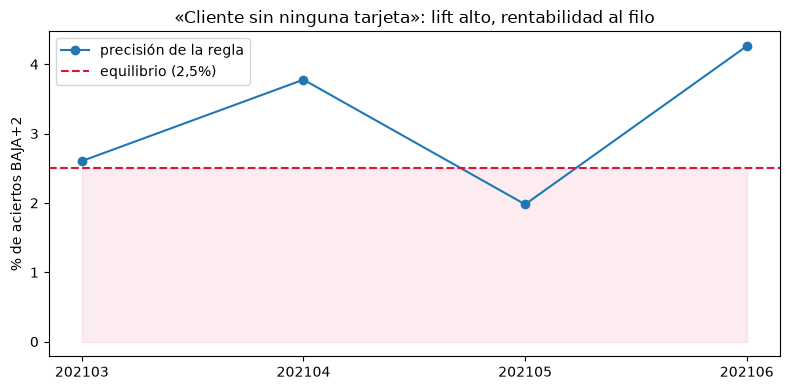

In [9]:
g = q(f"""
WITH d AS (SELECT foto_mes, clase_ternaria, {BASE} FROM c01 WHERE foto_mes <= 202106)
SELECT foto_mes,
  100.0*count(*) FILTER (WHERE sin_tarjeta=1 AND clase_ternaria='BAJA+2')
      / nullif(count(*) FILTER (WHERE sin_tarjeta=1), 0) AS precision_pct
FROM d GROUP BY foto_mes ORDER BY foto_mes
""")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(g["foto_mes"].astype(str), g["precision_pct"], marker="o", label="precisión de la regla")
ax.axhline(100 * umbral_negocio, ls="--", color="crimson", label="equilibrio (2,5%)")
ax.fill_between(g["foto_mes"].astype(str), 0, 100 * umbral_negocio, alpha=0.08, color="crimson")
ax.set_ylabel("% de aciertos BAJA+2")
ax.set_title("«Cliente sin ninguna tarjeta»: lift alto, rentabilidad al filo")
ax.legend()
plt.tight_layout()

**Hay lift** (3,9-6,7, con el piso de CONTINUA clavado en
3,8–3,9% los 4 meses). **Sin embargo, como regla de negocio no sirve**: la precisión
oscila alrededor del 2,5% y en **202105 cae a 1,98%**.

La razón es que, con una clase positiva del ~0,7%, un lift de 5× deja la
precisión en ~3,8%, apenas encima del equilibrio, y la varianza mensual cruza la
línea. **Un lift alto no implica rentabilidad cuando la clase es así de rara (~0,7%).**

Conclusión: es buena *feature* y mala *regla*. Va al modelo, pero no sirve para pensar una campaña.

## ¿Qué métrica hay que optimizar?

`leaf_df` tiene el conteo de cada clase por hoja, ordenadas por probabilidad de
BAJA+2. Recorrer esa tabla de arriba hacia abajo equivale a ir bajando el punto de
corte: cada fila es "estimular a las primeras k hojas".

Sobre esos cortes se calculan accuracy, sensibilidad, especificidad, F1 y ganancia,
y se busca dónde optimiza cada una.

In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree
from sklearn.metrics import roc_auc_score


# Reconstruyo el árbol de z201_sobre_árboles
mes_analisis = 202104
data = q(f"SELECT * FROM c01 WHERE foto_mes = {mes_analisis}")

X = data.drop("clase_ternaria", axis=1)
y = data["clase_ternaria"]

model = DecisionTreeClassifier(
    criterion="gini",
    random_state=SEMILLA,      
    min_samples_split=80,
    min_samples_leaf=1,
    max_depth=5,
).fit(X, y)


def get_leaf_info(tree):
    """Una fila por hoja, con el conteo de cada clase. Igual que z201."""
    t = tree.tree_
    filas = []
    for i in range(t.node_count):
        if t.children_left[i] == _tree.TREE_LEAF:
            conteos = t.value[i][0] * int(t.n_node_samples[i])
            fila = {"Node": i, "Samples": int(t.n_node_samples[i])}
            for j, clase in enumerate(tree.classes_):
                fila[clase] = int(round(conteos[j]))
            filas.append(fila)
    return pd.DataFrame(filas)


leaf_df = get_leaf_info(model)
leaf_df["prob_baja_2"] = leaf_df["BAJA+2"] / leaf_df["Samples"]
leaf_df = leaf_df.sort_values("prob_baja_2", ascending=False).reset_index(drop=True)
leaf_df["evento"] = leaf_df["BAJA+2"]
leaf_df["no_evento"] = leaf_df["CONTINUA"] + leaf_df["BAJA+1"]

print(f"{mes_analisis}: {len(data):,} filas | {model.get_n_leaves()} hojas | "
      f"{leaf_df['BAJA+2'].sum()} BAJA+2")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

202104: 163,284 filas | 24 hojas | 1139 BAJA+2


In [14]:
tot_ev = leaf_df["evento"].sum()
tot_no = leaf_df["no_evento"].sum()

cortes = pd.DataFrame({
    "corte_prob": [1.0] + leaf_df["prob_baja_2"].tolist(),
    "TP": [0] + leaf_df["evento"].cumsum().tolist(),
    "FP": [0] + leaf_df["no_evento"].cumsum().tolist(),
})
cortes["FN"] = tot_ev - cortes["TP"]
cortes["TN"] = tot_no - cortes["FP"]
cortes["estimulados"] = cortes["TP"] + cortes["FP"]

cortes["accuracy"]      = (cortes.TP + cortes.TN) / (tot_ev + tot_no)
cortes["sensibilidad"]  = cortes.TP / (cortes.TP + cortes.FN)
cortes["especificidad"] = cortes.TN / (cortes.TN + cortes.FP)
precision               = cortes.TP / (cortes.TP + cortes.FP).replace(0, np.nan)
cortes["precision"]     = precision
cortes["f1"]            = 2 * precision * cortes.sensibilidad / (precision + cortes.sensibilidad)
cortes["ganancia"]      = ganancia_acierto * cortes.TP - costo_estimulo * cortes.FP

print("===== ÓPTIMO DE CADA MÉTRICA =====")
for met in ["accuracy", "sensibilidad", "especificidad", "f1", "ganancia"]:
    r = cortes.loc[cortes[met].idxmax()]
    print(f"{met:<14} = {r[met]:>16,.4f} | corte {r.corte_prob:.4f} "
          f"| estimula {int(r.estimulados):>7,} | ganancia ${r.ganancia:>14,.0f}")

i_gan, i_f1 = cortes.ganancia.idxmax(), cortes.f1.idxmax()
print(f"\numbral de negocio (Bayes)   = {umbral_negocio:.4f}")
print(f"corte óptimo de ganancia    = {cortes.loc[i_gan,'corte_prob']:.4f}")
print(f"optimizar F1 deja sin capturar ${cortes.loc[i_gan,'ganancia'] - cortes.loc[i_f1,'ganancia']:,.0f}")

cortes[["corte_prob", "estimulados", "TP", "FP",
        "accuracy", "sensibilidad", "especificidad", "f1", "ganancia"]].round(4)

===== ÓPTIMO DE CADA MÉTRICA =====
accuracy       =           0.9930 | corte 1.0000 | estimula       1 | ganancia $     1,072,500
sensibilidad   =           1.0000 | corte 0.0007 | estimula 163,213 | ganancia $-3,235,457,500
especificidad  =           1.0000 | corte 1.0000 | estimula       0 | ganancia $             0
f1             =           0.2148 | corte 0.1552 | estimula   1,282 | ganancia $   250,745,000
ganancia       = 431,805,000.0000 | corte 0.0275 | estimula  12,098 | ganancia $   431,805,000

umbral de negocio (Bayes)   = 0.0250
corte óptimo de ganancia    = 0.0275
optimizar F1 deja sin capturar $181,060,000


,corte_prob,estimulados,TP,FP,accuracy,sensibilidad,especificidad,f1,ganancia
0,1.0000,0,0,0,0.9930,0.0000,1.0000,NaN,0
1,1.0000,1,1,0,0.9930,0.0009,1.0000,0.0018,1072500
2,0.5000,3,2,1,0.9930,0.0018,1.0000,0.0035,2117500
3,0.3740,134,51,83,0.9928,0.0448,0.9995,0.0801,52415000
4,0.1835,1224,251,973,0.9886,0.2204,0.9940,0.2124,242440000
5,0.1552,1282,260,1022,0.9884,0.2283,0.9937,0.2148,250745000
6,0.0923,1347,266,1081,0.9880,0.2335,0.9933,0.2140,255557500
7,0.0769,1360,267,1093,0.9880,0.2344,0.9933,0.2137,256300000
8,0.0769,3505,432,3073,0.9769,0.3793,0.9810,0.1860,378812500
9,0.0556,3523,433,3090,0.9768,0.3802,0.9809,0.1858,379417500


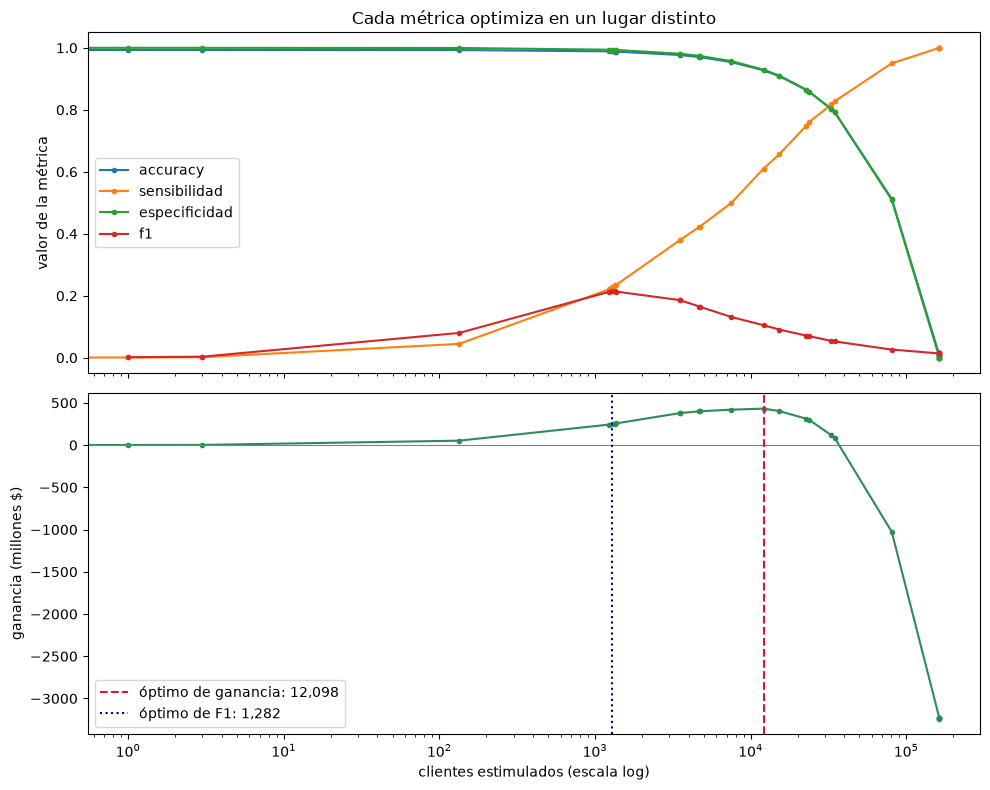

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for met in ["accuracy", "sensibilidad", "especificidad", "f1"]:
    ax1.plot(cortes["estimulados"], cortes[met], marker=".", label=met)
ax1.set_ylabel("valor de la métrica")
ax1.set_title("Cada métrica optimiza en un lugar distinto")
ax1.legend()

ax2.plot(cortes["estimulados"], cortes["ganancia"] / 1e6, marker=".", color="seagreen")
ax2.axhline(0, color="grey", lw=0.8)
ax2.axvline(cortes.loc[i_gan, "estimulados"], ls="--", color="crimson",
            label=f"óptimo de ganancia: {int(cortes.loc[i_gan,'estimulados']):,}")
ax2.axvline(cortes.loc[i_f1, "estimulados"], ls=":", color="navy",
            label=f"óptimo de F1: {int(cortes.loc[i_f1,'estimulados']):,}")
ax2.set_xlabel("clientes estimulados (escala log)")
ax2.set_ylabel("ganancia (millones $)")
ax2.set_xscale("log")
ax2.legend()
plt.tight_layout()

**Ninguna de las cuatro métricas típicas sirve en este problema.**

| Métrica | Óptimo | Estimula | Ganancia |
|---|---|---|---|
| Accuracy | 0,9930 | 1 cliente | $1.072.500 |
| Especificidad | 1,0000 | 0 clientes | $0 |
| Sensibilidad | 1,0000 | 163.213 | −$3.235.457.500 |
| F1 | 0,2148 | 1.282 | $250.745.000 |
| **Ganancia** | — | **12.098** | **$431.805.000** |

Accuracy y especificidad se maximizan **no haciendo nada**: como el 99,3% de la base
no es BAJA+2, acertar "nadie se va" da 99,3% de aciertos. Sensibilidad se maximiza
estimulando a todos.

F1 es la más sensata de las cuatro y aun así erra por mucho: propone
1.282 estímulos cuando convienen 12.098.

El corte que maximiza ganancia cae en **0,0275**, apenas encima del umbral de
Bayes **0,0250 = costo_estímulo / (ganancia_acierto + costo_estímulo)**. 
La métrica se deriva de los costos del negocio. 

## Variar parámetros: ¿AUC o ganancia?

El script de la clase mira un solo mes. Con los seis se puede preguntar algo que un mes
no permite: **¿la variable que mejor discrimina en marzo sigue siendo la mejor en
junio?** Se calcula el AUC univariado de cada feature por separado en cada foto.

AUC de Mann-Whitney sobre las filas **no nulas** (el NaN se analiza aparte, en la
sección 3). Solo 202103–202106: son los únicos meses con las tres clases.

In [19]:
MESES = [202103, 202104, 202105, 202106]


def auc_univariado(s: pd.Series, pos: np.ndarray) -> float:
    """AUC de Mann-Whitney sobre las filas no nulas."""
    ok = s.notna().to_numpy()
    if ok.sum() == 0:
        return np.nan
    v, p = s[ok], pos[ok]
    npos, nneg = int(p.sum()), int((~p.astype(bool)).sum())
    if npos == 0 or nneg == 0:
        return np.nan
    r = v.rank(method="average").to_numpy()
    return (r[p.astype(bool)].sum() - npos * (npos + 1) / 2) / (npos * nneg)


out = {}
for mes in MESES:
    d = q(f"SELECT * FROM c01 WHERE foto_mes = {mes}")
    pos = (d["clase_ternaria"] == "BAJA+2").to_numpy().astype(int)
    out[mes] = {c: auc_univariado(d[c], pos) for c in feat}
    print(f"  {mes}: {len(d):,} filas")

auc = pd.DataFrame(out)
auc_abs = (auc - 0.5).abs() + 0.5          # 0,20 discrimina tanto como 0,80
auc["prom"] = auc_abs.mean(axis=1)
auc["amplitud"] = auc_abs.max(axis=1) - auc_abs.min(axis=1)

print("\n===== TOP 20 por AUC promedio =====")
display(auc.sort_values("prom", ascending=False).head(20).round(3))

print("===== Las más inestables entre meses (con señal: prom > 0,60) =====")
display(auc[auc["prom"] > 0.60].sort_values("amplitud", ascending=False).head(10).round(3))

rk = auc_abs.rank(ascending=False).astype(int)
top = auc.sort_values("prom", ascending=False).head(12).index
print("===== Puesto de cada variable, mes a mes =====")
display(rk.loc[top])
print(f"Spearman entre el ranking de 202103 y el de 202106: "
      f"{auc_abs[202103].corr(auc_abs[202106], method='spearman'):.3f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  202103: 162,900 filas


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  202104: 163,284 filas


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

===== Las más inestables entre meses (con señal: prom > 0,60) =====


,202103,202104,202105,202106,prom,amplitud
Master_Finiciomora,0.733,0.689,0.485,0.568,0.626,0.218
Visa_Finiciomora,0.668,0.634,0.578,0.598,0.620,0.090
thomebanking,0.382,0.363,0.424,0.384,0.612,0.061
chomebanking_transacciones,0.291,0.275,0.333,0.294,0.702,0.058
cproductos,0.297,0.263,0.318,0.291,0.707,0.055
Master_mpagospesos,0.580,0.631,0.600,0.615,0.606,0.051
mactivos_margen,0.680,0.718,0.673,0.668,0.685,0.051
ctarjeta_visa,0.401,0.371,0.420,0.372,0.609,0.050
mcuentas_saldo,0.238,0.228,0.266,0.220,0.762,0.046
ctarjeta_visa_transacciones,0.243,0.210,0.256,0.231,0.765,0.046


===== Puesto de cada variable, mes a mes =====


,202103,202104,202105,202106
ctrx_quarter,1,1,1,1
mcaja_ahorro,2,2,2,2
mpasivos_margen,3,3,3,3
mtarjeta_visa_consumo,4,4,5,6
ctarjeta_visa_transacciones,9,5,7,8
mautoservicio,5,7,4,5
mcuentas_saldo,6,6,10,4
ctarjeta_debito_transacciones,7,8,6,7
ccomisiones_otras,8,9,11,9
mpayroll,10,13,8,10


Spearman entre el ranking de 202103 y el de 202106: 0.967


**El ranking de variables es muy estable**: Spearman 0,967 entre marzo y junio, y
el top 3 (`ctrx_quarter`, `mcaja_ahorro`, `mpasivos_margen`) es idéntico los cuatro
meses. `ctrx_quarter` tiene AUC 0,84 promedio y nunca baja de 0,81.

Los AUC por debajo de 0,5 indican relación **inversa**: `ctrx_quarter` da 0,165, es
decir que **valores bajos** señalan BAJA+2. Es lo esperable — el cliente que se va
deja de operar.

**La excepción son las variables de mora.** `Master_Finiciomora` va de 0,733 en
marzo a **0,485 en mayo**: de predictor fuerte a ruido. Con solo ~1% de clientes en
mora, unas pocas decenas de casos mueven el AUC entero. Suena a que conviene desconfiar 
de cualquier regla apoyada en mora.

## 7. ¿El mejor modelo por AUC es el que más plata da?

Varío los parámetros del árbol y comparo AUC y ganancia. Clave: se mide
sobre un **mes futuro** (202106), con el mismo gap de dos meses que usa z301.
Medir sobre el mes de entrenamiento solo diría que más profundidad es mejor. 
Igualmente incluyo ambos meses para comparar.

In [16]:
mes_train, mes_test = 202104, 202106
tr = q(f"SELECT * FROM c01 WHERE foto_mes = {mes_train}")
te = q(f"SELECT * FROM c01 WHERE foto_mes = {mes_test}")

Xtr, ytr = tr.drop("clase_ternaria", axis=1), tr["clase_ternaria"]
Xte = te.drop("clase_ternaria", axis=1)
ytr_b = (ytr == "BAJA+2").astype(int).to_numpy()
yte_b = (te["clase_ternaria"] == "BAJA+2").astype(int).to_numpy()


def ganancia_en_umbral(p, yb):
    """Ganancia estimulando a todo el que supere el umbral de negocio."""
    return int(np.where(p >= umbral_negocio,
                        np.where(yb == 1, ganancia_acierto, -costo_estimulo), 0).sum())


def ganancia_optima(p, yb):
    """Ganancia máxima alcanzable si se conociera el corte ideal de antemano."""
    orden = np.argsort(p)[::-1]
    return int(np.cumsum(np.where(yb[orden] == 1, ganancia_acierto, -costo_estimulo)).max())


def evaluar(**params):
    m = DecisionTreeClassifier(criterion="gini", random_state=SEMILLA, **params).fit(Xtr, ytr)
    j = list(m.classes_).index("BAJA+2")
    ptr, pte = m.predict_proba(Xtr)[:, j], m.predict_proba(Xte)[:, j]
    return {
        "max_depth": params.get("max_depth"),
        "min_leaf": params.get("min_samples_leaf"),
        "hojas": m.get_n_leaves(),
        "AUC_train": round(roc_auc_score(ytr_b, ptr), 4),
        "AUC_futuro": round(roc_auc_score(yte_b, pte), 4),
        "gan_train": ganancia_optima(ptr, ytr_b),
        "gan_futuro": ganancia_en_umbral(pte, yte_b),
    }


configs = [
    dict(max_depth=3,    min_samples_split=80,   min_samples_leaf=1),
    dict(max_depth=5,    min_samples_split=80,   min_samples_leaf=1),   # el del script original
    dict(max_depth=8,    min_samples_split=80,   min_samples_leaf=1),
    dict(max_depth=12,   min_samples_split=80,   min_samples_leaf=1),
    dict(max_depth=None, min_samples_split=80,   min_samples_leaf=1),
    dict(max_depth=8,    min_samples_split=200,  min_samples_leaf=100),
    dict(max_depth=12,   min_samples_split=1000, min_samples_leaf=500),
]
res = pd.DataFrame([evaluar(**c) for c in configs])

print(res.to_string(index=False))
print(f"\nmejor AUC_futuro : depth={res.loc[res.AUC_futuro.idxmax(),'max_depth']} "
      f"-> ganancia ${res.loc[res.AUC_futuro.idxmax(),'gan_futuro']:,}")
print(f"mejor ganancia   : depth={res.loc[res.gan_futuro.idxmax(),'max_depth']} "
      f"-> ganancia ${res.loc[res.gan_futuro.idxmax(),'gan_futuro']:,}")
print(f"\nSpearman AUC_futuro vs ganancia : {res.AUC_futuro.corr(res.gan_futuro, method='spearman'):.3f}")
print(f"Spearman AUC_train  vs ganancia : {res.AUC_train.corr(res.gan_futuro, method='spearman'):.3f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 max_depth  min_leaf  hojas  AUC_train  AUC_futuro  gan_train  gan_futuro
       3.0         1      8     0.8127      0.7980  369105000   278602500
       5.0         1     24     0.8802      0.8568  440412500   233227500
       8.0         1     76     0.9013      0.8671  478390000   228690000
      12.0         1    205     0.9200      0.8549  567545000   236417500
       NaN         1   1114     0.9905      0.6324 1011120000   133512500
       8.0       100     96     0.9197      0.8084  562375000   217662500
      12.0       500    117     0.9296      0.8395  523270000   271095000

mejor AUC_futuro : depth=8.0 -> ganancia $228,690,000
mejor ganancia   : depth=3.0 -> ganancia $278,602,500

Spearman AUC_futuro vs ganancia : 0.107
Spearman AUC_train  vs ganancia : -0.429


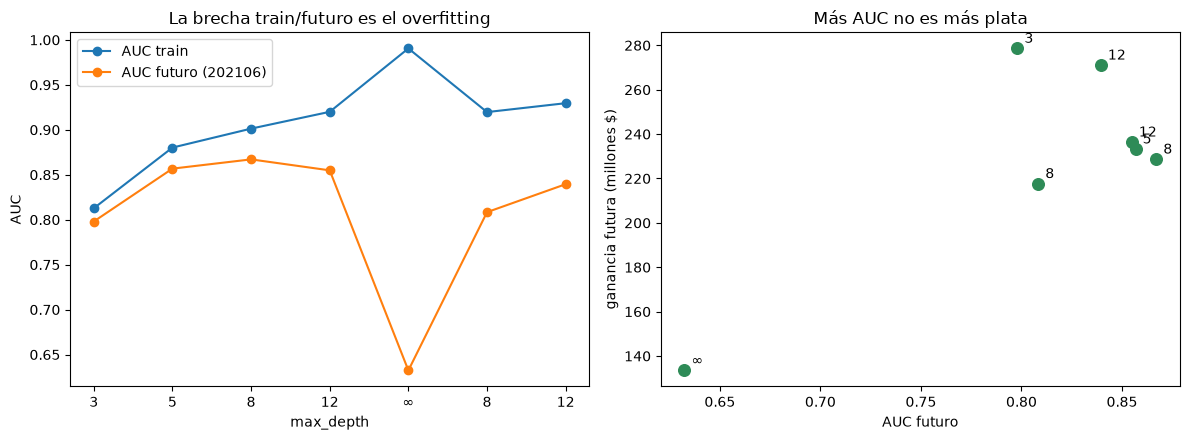

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

etiquetas = [("∞" if pd.isna(d) else f"{int(d)}") for d in res["max_depth"]]
x = range(len(res))
ax1.plot(x, res["AUC_train"], marker="o", label="AUC train")
ax1.plot(x, res["AUC_futuro"], marker="o", label="AUC futuro (202106)")
ax1.set_xticks(list(x)); ax1.set_xticklabels(etiquetas)
ax1.set_xlabel("max_depth"); ax1.set_ylabel("AUC")
ax1.set_title("La brecha train/futuro es el overfitting")
ax1.legend()

ax2.scatter(res["AUC_futuro"], res["gan_futuro"] / 1e6, s=70, color="seagreen")
for _, r in res.iterrows():
    ax2.annotate("∞" if pd.isna(r.max_depth) else f"{int(r.max_depth)}",
                 (r.AUC_futuro, r.gan_futuro / 1e6), xytext=(5, 4), textcoords="offset points")
ax2.set_xlabel("AUC futuro"); ax2.set_ylabel("ganancia futura (millones $)")
ax2.set_title("Más AUC no es más plata")
plt.tight_layout()

**Tres conclusiones:**

1. **El overfitting se ve.** El árbol sin podar (1.114 hojas) llega a AUC 0,9905 en
   train y se desploma a **0,6324** en el mes futuro.

2. **AUC y ganancia no coinciden.** El de mejor AUC futuro (`max_depth=8`) da
   $228.690.000; el de mejor ganancia (`max_depth=3`) tiene casi el peor AUC (0,7980)
   y da $278.602.500. Spearman entre ambos rankings: **0,107** — prácticamente
   independientes.

3. **Elegir por AUC de train es peor que tirar una moneda.** Spearman entre AUC de
   train y ganancia futura: **−0,429**, *negativa*. El modelo que mejor mide en train
   tiende a ser el que peor rinde después.

**Recordatorio para mí mismo:** esto es una corrida, una semilla y un par de meses.
Las diferencias pueden ser ruido. La medición seria —muchas particiones, mirar media
y dispersión, comparar con Wilcoxon pareado— es la tarea de z301. Acá alcanza para
mostrar que el desacople existe.

## 8. ¿Cómo es el cliente que se va?

Ya vi qué variables discriminan. Acá se ve *cómo*: medianas por
clase, porcentaje de clientes en cero, y tablas de contingencia de las categóricas.

In [20]:
TOP = auc.sort_values("prom", ascending=False).head(20).index.tolist()
PERFIL = [c for c in TOP if c not in ("Visa_msaldopesos",)] + ["mrentabilidad", "cliente_antiguedad"]

filas = []
for c in PERFIL:
    r = {"variable": c}
    for cl in ["CONTINUA", "BAJA+1", "BAJA+2"]:
        s = data.loc[data.clase_ternaria == cl, c]
        r[f"med_{cl}"] = s.median()
        r[f"cero_{cl}"] = 100 * (s.fillna(0) == 0).mean()
    mc = r["med_CONTINUA"]
    r["ratio_b2_cont"] = r["med_BAJA+2"] / mc if pd.notna(mc) and mc != 0 else np.nan
    r["pp_cero_extra"] = r["cero_BAJA+2"] - r["cero_CONTINUA"]
    filas.append(r)
perfil = pd.DataFrame(filas)

print("===== 8.1 Mediana por clase =====")
display(perfil[["variable", "med_CONTINUA", "med_BAJA+1", "med_BAJA+2", "ratio_b2_cont"]].round(2))

print("===== 8.2 % de clientes en cero =====")
display(perfil[["variable", "cero_CONTINUA", "cero_BAJA+1", "cero_BAJA+2", "pp_cero_extra"]]
        .round(1).sort_values("pp_cero_extra", ascending=False))

===== 8.1 Mediana por clase =====


,variable,med_CONTINUA,med_BAJA+1,med_BAJA+2,ratio_b2_cont
0,ctrx_quarter,106.00,18.00,17.00,0.16
1,mcaja_ahorro,22637.91,129.13,59.37,0.00
2,mpasivos_margen,660.49,37.33,47.09,0.07
3,mtarjeta_visa_consumo,19166.61,0.00,0.00,0.00
4,ctarjeta_visa_transacciones,9.00,0.00,0.00,0.00
5,mautoservicio,8760.30,0.00,0.00,0.00
6,mcuentas_saldo,34084.71,-1917.24,-1805.25,-0.05
7,ctarjeta_debito_transacciones,4.00,0.00,0.00,0.00
8,ccomisiones_otras,8.00,4.00,4.00,0.50
9,mpayroll,32636.96,0.00,0.00,0.00


===== 8.2 % de clientes en cero =====


,variable,cero_CONTINUA,cero_BAJA+1,cero_BAJA+2,pp_cero_extra
5,mautoservicio,29.1,79.7,76.5,47.4
7,ctarjeta_debito_transacciones,29.1,79.7,76.5,47.4
10,cpayroll_trx,45.3,95.4,91.3,46.0
9,mpayroll,45.9,95.4,91.3,45.4
4,ctarjeta_visa_transacciones,14.3,57.6,58.7,44.4
3,mtarjeta_visa_consumo,14.3,57.6,58.7,44.4
13,Visa_mpagominimo,17.7,55.5,59.7,42.0
17,mtransferencias_emitidas,39.6,76.5,79.9,40.3
16,ctransferencias_emitidas,39.6,76.5,79.9,40.3
11,Visa_msaldototal,12.9,47.5,52.5,39.6


In [21]:
tasa_base = 100 * (data.clase_ternaria == "BAJA+2").mean()
print(f"tasa base BAJA+2 = {tasa_base:.3f}%\n")

for var in ["Master_status", "Visa_status", "active_quarter", "internet", "cliente_vip"]:
    # .astype("object") porque DuckDB devuelve Int64 nullable y no acepta un string en fillna
    col = data[var].astype("object").where(data[var].notna(), "NULO")
    t = pd.crosstab(col, data.clase_ternaria, normalize="index") * 100
    t["n"] = pd.crosstab(col, data.clase_ternaria).sum(axis=1)
    t["lift_B2"] = (t["BAJA+2"] / tasa_base).round(2)
    print(f"--- {var} ---")
    display(t.round(2))

tasa base BAJA+2 = 0.698%

--- Master_status ---


clase_ternaria,BAJA+1,BAJA+2,CONTINUA,n,lift_B2
Master_status,,,,,
0,0.39,0.49,99.13,145897,0.70
6,44.44,22.22,33.33,9,31.86
7,8.04,14.15,77.81,311,20.28
9,26.53,9.80,63.67,245,14.04
NULO,1.79,2.13,96.08,16822,3.05


--- Visa_status ---


clase_ternaria,BAJA+1,BAJA+2,CONTINUA,n,lift_B2
Visa_status,,,,,
0,0.41,0.51,99.08,154693,0.73
6,42.86,14.29,42.86,14,20.48
7,5.49,5.78,88.73,346,8.29
9,30.33,9.43,60.25,244,13.51
NULO,2.79,3.84,93.36,7987,5.51


--- active_quarter ---


clase_ternaria,BAJA+1,BAJA+2,CONTINUA,n,lift_B2
active_quarter,,,,,
0,6.77,9.05,84.18,2143,12.98
1,0.50,0.59,98.91,161141,0.84


--- internet ---


clase_ternaria,BAJA+1,BAJA+2,CONTINUA,n,lift_B2
internet,,,,,
0,0.54,0.62,98.84,155824,0.89
1,2.04,2.61,95.35,5247,3.74
2,0.82,1.82,97.36,1706,2.60
3,0.20,0.20,99.60,503,0.29
4,0.00,0.00,100.00,4,0.00


--- cliente_vip ---


clase_ternaria,BAJA+1,BAJA+2,CONTINUA,n,lift_B2
cliente_vip,,,,,
0,0.59,0.70,98.71,162858,1.00
1,0.23,0.23,99.53,426,0.34


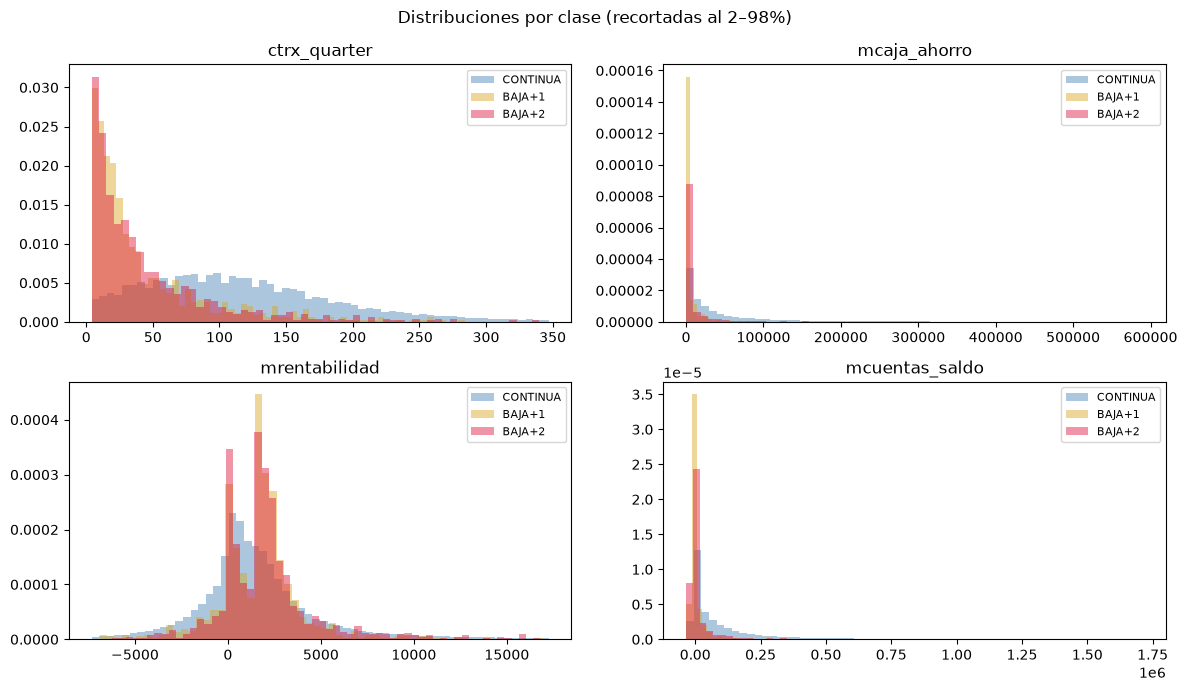

In [22]:
VER = ["ctrx_quarter", "mcaja_ahorro", "mrentabilidad", "mcuentas_saldo"]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for ax, c in zip(axes.ravel(), VER):
    s = data[c].astype(float)
    lo, hi = s.quantile(0.02), s.quantile(0.98)      # recorte, como hace z201 con mpasivos_margen
    for cl, color in [("CONTINUA", "steelblue"), ("BAJA+1", "goldenrod"), ("BAJA+2", "crimson")]:
        v = s[(data.clase_ternaria == cl) & s.between(lo, hi)]
        ax.hist(v, bins=60, density=True, alpha=0.45, label=cl, color=color)
    ax.set_title(c)
    ax.legend(fontsize=8)
fig.suptitle("Distribuciones por clase (recortadas al 2–98%)")
plt.tight_layout()

## 9. ¿Cuántas señales distintas hay?

No necesariamente cada de una de las 20 variables con AUC alto aporta información distinta.
Para chequear eso, agrupo por correlaciones de Spearman, que puede funcionar como un indicador
de cuántas cosas distintas miden estas 20 variables.

===== 9.1 Pares casi idénticos (|rho| >= 0.90) =====
  rho=+0.996   Visa_msaldopesos                 <-> Visa_msaldototal                 (AUC 0.730 / 0.729)
  rho=+0.927   mautoservicio                    <-> ctarjeta_debito_transacciones    (AUC 0.764 / 0.760)
  rho=+0.921   ctransferencias_emitidas         <-> mtransferencias_emitidas         (AUC 0.700 / 0.697)
  rho=+0.920   mtarjeta_visa_consumo            <-> Visa_msaldopesos                 (AUC 0.769 / 0.730)
  rho=+0.917   mtarjeta_visa_consumo            <-> Visa_msaldototal                 (AUC 0.769 / 0.729)

===== 9.2 Grupos que miden lo mismo (|rho| >= 0.80) =====

Grupo 1: mtarjeta_visa_consumo, ctarjeta_visa_transacciones, Visa_msaldopesos, Visa_msaldototal
    representante: mtarjeta_visa_consumo (AUC 0.769)

Grupo 5: mpayroll, cpayroll_trx
    representante: mpayroll (AUC 0.740)

Grupo 6: mautoservicio, ctarjeta_debito_transacciones
    representante: mautoservicio (AUC 0.764)

Grupo 13: ctransferencias_emitidas, mtr

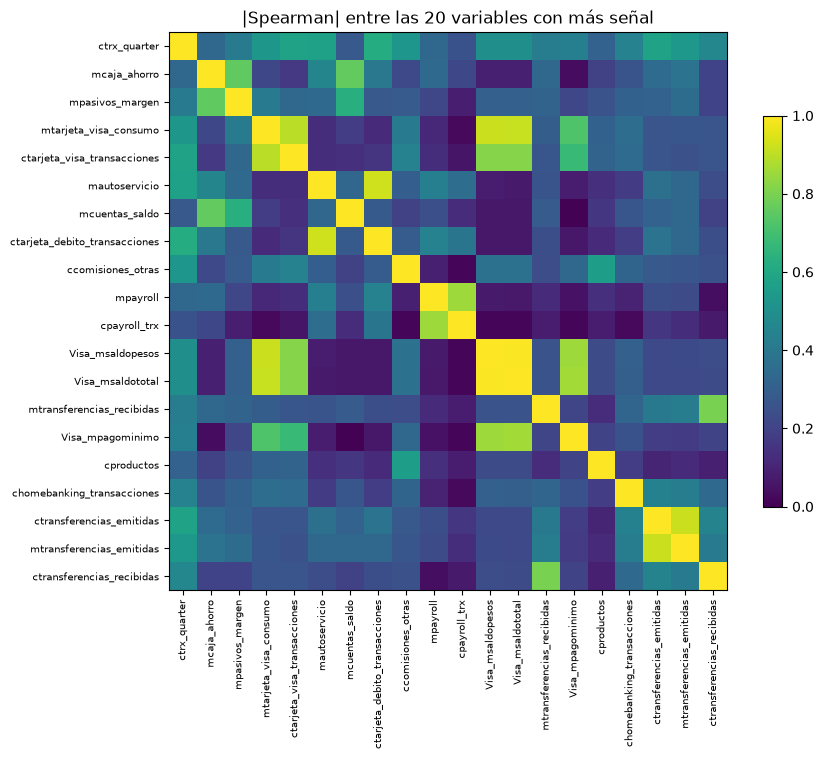

In [23]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

X = data[TOP].apply(pd.to_numeric, errors="coerce")
C = X.corr(method="spearman")

print("===== 9.1 Pares casi idénticos (|rho| >= 0.90) =====")
for a, b, r in sorted(
    [(a, b, C.loc[a, b]) for i, a in enumerate(TOP) for b in TOP[i + 1:] if abs(C.loc[a, b]) >= 0.90],
    key=lambda x: -abs(x[2]),
):
    print(f"  rho={r:+.3f}   {a:<32} <-> {b:<32} (AUC {auc.loc[a,'prom']:.3f} / {auc.loc[b,'prom']:.3f})")

Dv = (1 - C.abs()).to_numpy(copy=True)
np.fill_diagonal(Dv, 0)
grupos = fcluster(linkage(squareform(Dv, checks=False), method="average"), t=0.20, criterion="distance")

g = (pd.DataFrame({"variable": TOP, "grupo": grupos, "AUC": auc.loc[TOP, "prom"].to_numpy()})
       .sort_values(["grupo", "AUC"], ascending=[True, False]))
print("\n===== 9.2 Grupos que miden lo mismo (|rho| >= 0.80) =====")
for k, sub in g.groupby("grupo"):
    if len(sub) > 1:
        print(f"\nGrupo {k}: {', '.join(sub.variable)}")
        print(f"    representante: {sub.iloc[0].variable} (AUC {sub.iloc[0].AUC:.3f})")
print(f"\n>>> {len(TOP)} variables se reducen a {g.grupo.nunique()} señales distintas")

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(C.abs(), cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(TOP))); ax.set_xticklabels(TOP, rotation=90, fontsize=7)
ax.set_yticks(range(len(TOP))); ax.set_yticklabels(TOP, fontsize=7)
ax.set_title("|Spearman| entre las 20 variables con más señal")
fig.colorbar(im, shrink=0.7)
plt.tight_layout()

**Los pares casi idénticos son pocos**: `Visa_msaldopesos` y
`Visa_msaldototal` y el bloque de actividad Visa (consumo, transacciones y saldo).

## 10. Catálogo completo de TODAS las variables del dataset

Decidí armar una tabla de referencia con las 152 variabels: tipo, unidad 
y significado según el diccionario de variables, cuántos valores distintos toman, 
qué porcentaje está en cero o nulo, rango, asimetría, AUC univariado, 
y cómo difieren las medianas entre clases.

In [28]:
DICCIONARIO = os.path.join(raiz, "fernando", "dmeyf2026-9c6f_DiccionarioDatos_2026.ods")

dic = (pd.read_excel(DICCIONARIO, engine="odf")
         .rename(columns={"campo": "variable", "Significado": "significado"})
         .set_index("variable")[["unidad", "significado"]])

pos_b2 = (data.clase_ternaria == "BAJA+2").to_numpy().astype(int)

filas = []
for c in feat:
    s = pd.to_numeric(data[c], errors="coerce")
    a = auc_univariado(s, pos_b2)
    sc = s[data.clase_ternaria == "CONTINUA"]
    sb = s[data.clase_ternaria == "BAJA+2"]
    filas.append({
        "variable": c,
        "n_unicos": int(s.nunique(dropna=True)),
        "pct_null": 100 * s.isna().mean(),
        "pct_cero": 100 * (s.fillna(0) == 0).mean(),
        "pct_neg": 100 * (s < 0).mean(),
        "min": s.min(), "p50": s.median(), "max": s.max(),
        "skew": s.skew(),
        "auc": a,
        "auc_abs": abs(a - 0.5) + 0.5 if pd.notna(a) else np.nan,
        "p50_CONT": sc.median(), "p50_B2": sb.median(),
        "cero_extra_pp": 100 * ((sb.fillna(0) == 0).mean() - (sc.fillna(0) == 0).mean()),
    })

catalogo = pd.DataFrame(filas).set_index("variable").join(dic)
catalogo["tipo"] = np.select(
    [catalogo.n_unicos <= 2, catalogo.n_unicos <= 12, catalogo.unidad == "pesos"],
    ["binaria", "categorica", "monto"], default="conteo/continua")

print("===== Composición del dataset =====")
display(pd.crosstab(catalogo.unidad.fillna("?"), catalogo.tipo))
print(f"total features: {len(catalogo)}")

catalogo.sort_values("auc_abs", ascending=False).head(25).round(3)

===== Composición del dataset =====


tipo,binaria,categorica,conteo/continua,monto
unidad,,,,
--,11,23,34,0
?,0,1,1,0
años,0,0,1,0
dias,0,0,8,0
meses,0,0,1,0
pesos,0,1,0,71


total features: 152


,n_unicos,pct_null,pct_cero,pct_neg,min,p50,max,skew,auc,auc_abs,p50_CONT,p50_B2,cero_extra_pp,unidad,significado,tipo
variable,,,,,,,,,,,,,,,,
ctrx_quarter,838,0.000,1.031,0.000,0.00,105.000,3.437000e+03,2.827,0.143,0.857,106.000,17.000,13.968,--,Cantidad de movimientos voluntarios en las cue...,conteo/continua
mcaja_ahorro,148837,0.000,7.288,0.008,-8280.13,22124.215,3.078795e+07,32.073,0.182,0.818,22637.910,59.370,36.885,pesos,Monto total de la caja de ahorro del Paquete P...,monto
mpasivos_margen,119788,0.000,1.283,3.469,-62197.19,649.390,5.190438e+05,29.581,0.200,0.800,660.490,47.090,12.497,pesos,Monto total de la ganancia que el banco ha obt...,monto
mtarjeta_visa_consumo,134839,0.000,14.902,0.000,0.00,18855.520,2.837241e+06,8.646,0.207,0.793,19166.605,0.000,44.397,pesos,Monto total de los consumos efectuados durante...,monto
ctarjeta_visa_transacciones,191,0.000,14.902,0.000,0.00,9.000,6.340000e+02,3.721,0.210,0.790,9.000,0.000,44.397,--,Cantidad de transacciones efectuadas durante e...,conteo/continua
mcuentas_saldo,160108,0.000,0.624,20.367,-2232579.79,32804.150,3.287445e+08,98.548,0.228,0.772,34084.710,-1805.250,1.064,pesos,Saldo total de TODAS las cuentas del cliente,monto
mautoservicio,102253,0.000,29.701,0.000,0.00,8469.105,1.400273e+06,4.225,0.233,0.767,8760.305,0.000,47.397,pesos,Monto total de las transacciones que hizo el c...,monto
ctarjeta_debito_transacciones,124,0.000,29.701,0.000,0.00,4.000,1.620000e+02,2.310,0.236,0.764,4.000,0.000,47.397,--,Cantidad de transacciones que hizo el cliente ...,conteo/continua
ccomisiones_otras,164,0.000,2.524,0.000,0.00,8.000,2.560000e+02,13.705,0.240,0.760,8.000,4.000,8.033,--,Cantidad de otras comisiones que se cobraron a...,conteo/continua


In [29]:
sin_senal = catalogo[catalogo.auc_abs < 0.53].sort_values("pct_cero", ascending=False)
print(f"{len(sin_senal)} variables sin señal ({100*len(sin_senal)/len(catalogo):.0f}% del dataset)")
print(f"de ellas, {(sin_senal.pct_cero > 95).sum()} están vacías en más del 95% de los clientes")
display(sin_senal[["unidad", "n_unicos", "pct_cero", "auc_abs", "significado"]].head(20))

print("===== Zero-inflation: forma típica del dataset =====")
display(pd.cut(catalogo.pct_cero, [0, 1, 25, 50, 75, 95, 100], include_lowest=True)
          .value_counts().sort_index().rename("variables"))

73 variables sin señal (48% del dataset)
de ellas, 54 están vacías en más del 95% de los clientes


,unidad,n_unicos,pct_cero,auc_abs,significado
variable,,,,,
Master_madelantodolares,pesos,7,99.996325,0.500046,Extracciones de dolares realizadas con la tarj...
Visa_madelantodolares,pesos,18,99.989589,0.500060,Extracciones de dolares realizadas con la tarj...
mcuenta_corriente_adicional,pesos,85,99.948556,0.500257,Monto total de las cuentas corrientes adiciona...
mpayroll2,pesos,129,99.911198,0.500447,Monto total que le acreditaron fuera de archiv...
cpayroll2_trx,--,5,99.911198,0.500447,Cantidad de transacciones de acreditacion de h...
Master_madelantopesos,pesos,49,99.867103,0.501659,Extracciones de pesos realizadas con la tarjet...
Master_cadelantosefectivo,--,12,99.867103,0.501659,Cantidad de adelantos en efectivo que el clien...
mcheques_emitidos_rechazados,pesos,197,99.837706,0.500817,Monto total de cheques emitidos por el client...
ccheques_emitidos_rechazados,--,12,99.837706,0.500817,Cantidad de cheques emitidos por el cliente qu...


===== Zero-inflation: forma típica del dataset =====


pct_cero
(-0.001, 1.0]    10
(1.0, 25.0]      31
(25.0, 50.0]     16
(50.0, 75.0]     17
(75.0, 95.0]     20
(95.0, 100.0]    58
Name: variables, dtype: int64

In [30]:
print("===== Variables con valores negativos =====")
display(catalogo[catalogo.pct_neg > 0][["unidad", "pct_neg", "min", "p50"]]
        .sort_values("pct_neg", ascending=False).head(10).round(2))

print("===== Búsqueda de valores centinela =====")
# Un centinela se delata así: el valor extremo está aislado, lejísimos del siguiente.
for c in catalogo[catalogo.unidad == "dias"].index:
    s = pd.to_numeric(data[c], errors="coerce").dropna()
    if s.empty:
        continue
    v = np.sort(s.unique())
    salto = abs(v[1] - v[0]) if len(v) > 1 else 0
    if salto > 1000:
        print(f"{c}: valor {v[0]:,.0f} aislado — el siguiente es {v[1]:,.0f} "
              f"({int((s == v[0]).sum()):,} filas)")

from datetime import date
foto = date(2021, 4, 30)
print(f"\nfoto − 9999-12-31 = {(foto - date(9999,12,31)).days:,} días  (el centinela clásico)")

print("\n===== ¿Persiste en todos los meses? =====")
display(q("""
SELECT foto_mes,
       count(*) FILTER (WHERE Visa_Fvencimiento < -20000) AS centinelas,
       count(*) FILTER (WHERE Visa_Fvencimiento IS NOT NULL) AS con_dato
FROM c01 GROUP BY 1 ORDER BY 1
"""))

===== Variables con valores negativos =====


,unidad,pct_neg,min,p50
variable,,,,
Visa_Fvencimiento,dias,99.92,-2914148.00,-1309.00
Master_Fvencimiento,dias,99.90,-2251.00,-882.00
Visa_mpagospesos,pesos,84.38,-2855922.92,-22829.64
mactivos_margen,pesos,71.65,-313906.75,-581.88
mcuenta_corriente,pesos,45.35,-2195857.50,0.00
Master_mpagospesos,pesos,35.90,-1271748.38,-7044.42
mrentabilidad,pesos,26.57,-239774.32,1125.14
mrentabilidad_annual,pesos,20.38,-603976.89,12785.26
mcuentas_saldo,pesos,20.37,-2232579.79,32804.15


===== Búsqueda de valores centinela =====
Visa_Fvencimiento: valor -2,914,148 aislado — el siguiente es -2,251 (463 filas)

foto − 9999-12-31 = -2,914,149 días  (el centinela clásico)

===== ¿Persiste en todos los meses? =====


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,foto_mes,centinelas,con_dato
0,202103,466,155006
1,202104,463,155297
2,202105,458,155729
3,202106,454,155992
4,202107,449,157116
5,202108,446,156735


**El 47% del dataset son montos en pesos** (71 de 152).

**El 48% de las variables no tiene ninguna señal** (AUC ≈ 0,50), y en casi todas 
es porque están vacías en más del 95% de los clientes: forex, cheques rechazados, adelantos en
dólares, préstamos prendarios, segundo empleador, etc.

**58 variables tienen más del 95% de ceros.**

**`Visa_Fvencimiento` contiene un valor extremo.** El mínimo, −2.914.148 días
(≈ 7.980 años), corresponde a la fecha **9999-12-31**. Supongo que es un 
placeholder de "sin vencimiento" que sobrevivió a la conversión de fecha
absoluta a días relativos. **Corresponde convertirlo a NULL antes
de cualquier modelo que no sea basado en árboles.**

## ¿Qué le pasa al cliente antes de irse?

Todo lo anterior es transversal. Acá hago una aproximación longitudinal:
seguimos a los clientes a lo largo de los seis meses. 

Alineo cada BAJA+2 por **meses antes de la baja** (`t_rel`) en vez de por
`foto_mes`: t0 es la foto en que se lo etiqueta BAJA+2, t−1 el mes anterior, etc.
Se agrupan las cohortes de 202104, 202105 y 202106 para que cada `t_rel` mezcle
meses calendario distintos; si no, `t_rel` coincidiría con el mes y no se podría
distinguir el comportamiento de la estacionalidad (el aguinaldo de junio).

Grupo de control: clientes que continúan (presentes los seis meses, nunca BAJA+1 ni BAJA+2).

In [40]:
VARS_TRAY = ["mcomisiones_mantenimiento", "mcaja_ahorro", "ctrx_quarter",
             "mcuentas_saldo", "mrentabilidad", "mpayroll",
             "chomebanking_transacciones", "ctarjeta_visa_transacciones"]

con.execute("""
CREATE OR REPLACE TABLE alineado AS
WITH baja AS (
    SELECT numero_de_cliente, foto_mes AS mes_b2
    FROM c01 WHERE clase_ternaria = 'BAJA+2' AND foto_mes IN (202104, 202105, 202106)
), idx AS (
    SELECT DISTINCT foto_mes, dense_rank() OVER (ORDER BY foto_mes) AS i FROM c01
)
SELECT c.*, ib.i - im.i AS t_rel
FROM c01 c
JOIN baja b USING (numero_de_cliente)
JOIN idx ib ON ib.foto_mes = c.foto_mes
JOIN idx im ON im.foto_mes = b.mes_b2
WHERE ib.i - im.i BETWEEN -3 AND 0
""")

con.execute("""
CREATE OR REPLACE TABLE continuan AS
SELECT numero_de_cliente FROM c01 GROUP BY 1
HAVING count(*) = 6
   AND sum(CASE WHEN clase_ternaria IN ('BAJA+1','BAJA+2') THEN 1 ELSE 0 END) = 0
""")

sel = ", ".join(f"median({v}) AS {v}" for v in VARS_TRAY)

print("===== BAJA+2, alineados por meses antes de la baja =====")
display(q(f"""SELECT t_rel, count(DISTINCT numero_de_cliente) AS clientes,
                     count(DISTINCT foto_mes) AS meses_calendario, {sel}
              FROM alineado GROUP BY 1 ORDER BY 1""").round(0))

print("===== Control: clientes continuan, por mes calendario =====")
display(q(f"""SELECT foto_mes, {sel} FROM c01 JOIN continuan USING (numero_de_cliente)
              WHERE foto_mes <= 202106 GROUP BY 1 ORDER BY 1""").round(0))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

===== BAJA+2, alineados por meses antes de la baja =====


,t_rel,clientes,meses_calendario,mcomisiones_mantenimiento,mcaja_ahorro,ctrx_quarter,mcuentas_saldo,mrentabilidad,mpayroll,chomebanking_transacciones,ctarjeta_visa_transacciones
0,-3,1088,1,0.0,990.0,27.0,55.0,1575.0,0.0,3.0,1.0
1,-2,1957,2,887.0,934.0,26.0,13.0,1615.0,0.0,3.0,1.0
2,-1,3096,3,1623.0,422.0,22.0,-65.0,1665.0,0.0,2.0,0.0
3,0,3107,3,1774.0,111.0,21.0,-1142.0,1756.0,0.0,1.0,0.0


===== Control: clientes continuan, por mes calendario =====


,foto_mes,mcomisiones_mantenimiento,mcaja_ahorro,ctrx_quarter,mcuentas_saldo,mrentabilidad,mpayroll,chomebanking_transacciones,ctarjeta_visa_transacciones
0,202103,0.0,25742.0,106.0,36803.0,1231.0,35190.0,29.0,9.0
1,202104,0.0,23181.0,107.0,35389.0,1116.0,35190.0,26.0,9.0
2,202105,0.0,24080.0,107.0,34930.0,1226.0,40328.0,25.0,9.0
3,202106,0.0,26107.0,107.0,49939.0,1381.0,49388.0,23.0,10.0


In [41]:
# La mediana engaña cuando menos de la mitad del grupo tiene el atributo:
# da 0 aunque el 30% sí pague comisión. Hay que mirar la proporción.
print("===== % de clientes con comisión de mantenimiento > 0 =====")
display(q("""SELECT t_rel, count(*) AS filas,
                    round(100.0*avg(CASE WHEN mcomisiones_mantenimiento > 0 THEN 1 ELSE 0 END), 1) AS pct_BAJA2
             FROM alineado GROUP BY 1 ORDER BY 1"""))
display(q("""SELECT foto_mes,
                    round(100.0*avg(CASE WHEN mcomisiones_mantenimiento > 0 THEN 1 ELSE 0 END), 1) AS pct_continuan
             FROM c01 JOIN continuan USING (numero_de_cliente)
             WHERE foto_mes <= 202106 GROUP BY 1 ORDER BY 1"""))

===== % de clientes con comisión de mantenimiento > 0 =====


,t_rel,filas,pct_BAJA2
0,-3,1088,47.2
1,-2,1957,50.6
2,-1,3096,54.7
3,0,3107,61.3


,foto_mes,pct_continuan
0,202103,31.0
1,202104,30.2
2,202105,28.0
3,202106,31.0


===== BAJA+2 como % del cliente que continúa =====


,mcaja_ahorro,ctrx_quarter,chomebanking_transacciones,ctarjeta_visa_transacciones,mrentabilidad
t_rel,,,,,
-3,4.0,25.2,11.5,11.1,127.1
-2,3.8,24.3,11.5,11.1,130.3
-1,1.7,20.6,7.7,0.0,134.4
0,0.4,19.6,3.8,0.0,141.7


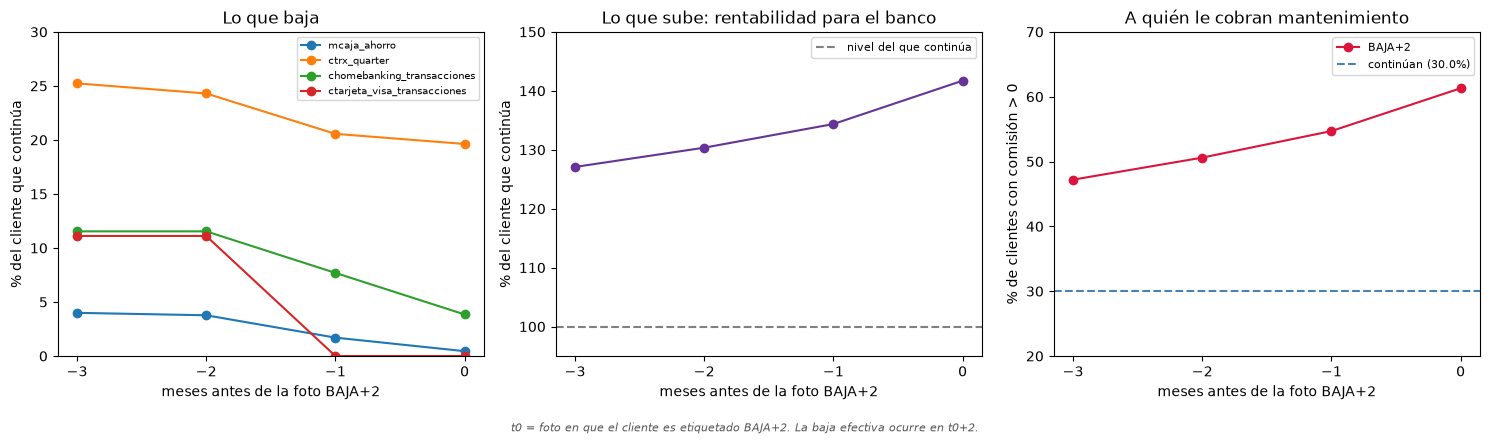

In [44]:
VARS_BAJAN = ["mcaja_ahorro", "ctrx_quarter", "chomebanking_transacciones",
              "ctarjeta_visa_transacciones"]
sel_r = ", ".join(f"median({v}) AS {v}" for v in VARS_BAJAN + ["mrentabilidad"])

b = q(f"SELECT t_rel, {sel_r} FROM alineado GROUP BY 1 ORDER BY 1").set_index("t_rel")
ref = q(f"""SELECT {sel_r} FROM c01 JOIN continuan USING (numero_de_cliente)
            WHERE foto_mes <= 202106""").iloc[0]
ratio = 100 * b / ref

print("===== BAJA+2 como % del cliente que continúa =====")
display(ratio.round(1))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.2))

# --- 1. lo que se apaga: todas caen muy por debajo de la referencia
for c in VARS_BAJAN:
    ax1.plot(ratio.index, ratio[c], marker="o", label=c)
ax1.set_ylim(0, 30)
ax1.set_title("Lo que baja")
ax1.set_ylabel("% del cliente que continúa")
ax1.legend(fontsize=7, loc="upper right")

# --- 2. lo que sube: rentabilidad, por encima de la referencia
ax2.plot(ratio.index, ratio["mrentabilidad"], marker="o", color="rebeccapurple")
ax2.axhline(100, ls="--", color="grey", label="nivel del que continúa")
ax2.set_ylim(95, 150)
ax2.set_title("Lo que sube: rentabilidad para el banco")
ax2.set_ylabel("% del cliente que continúa")
ax2.legend(fontsize=8)

# --- 3. comisiones: proporción de clientes, no monto (la mediana da 0 y engaña)
com = q("""SELECT t_rel, round(100.0*avg(CASE WHEN mcomisiones_mantenimiento > 0 THEN 1 ELSE 0 END), 1) AS pct
           FROM alineado GROUP BY 1 ORDER BY 1""")
ref_com = q("""SELECT round(100.0*avg(CASE WHEN mcomisiones_mantenimiento > 0 THEN 1 ELSE 0 END), 1) AS pct
               FROM c01 JOIN continuan USING (numero_de_cliente) WHERE foto_mes <= 202106""").iloc[0, 0]
ax3.plot(com.t_rel, com.pct, marker="o", color="crimson", label="BAJA+2")
ax3.axhline(ref_com, ls="--", color="steelblue", label=f"continúan ({ref_com}%)")
ax3.set_ylim(20, 70)
ax3.set_title("A quién le cobran mantenimiento")
ax3.set_ylabel("% de clientes con comisión > 0")
ax3.legend(fontsize=8)

for ax in (ax1, ax2, ax3):
    ax.set_xticks([-3, -2, -1, 0])
    ax.set_xlabel("meses antes de la foto BAJA+2")      # antes: "meses antes de la baja"

fig.text(0.5, -0.04,
         "t0 = foto en que el cliente es etiquetado BAJA+2. La baja efectiva ocurre en t0+2.",
         ha="center", fontsize=8, style="italic", color="#555")
plt.tight_layout()

In [43]:
print("===== Perfil demográfico por clase =====")
display(q("""SELECT clase_ternaria, count(*) AS n,
                    round(avg(cliente_edad), 1) AS edad_prom, median(cliente_edad) AS edad_med,
                    median(cliente_antiguedad) AS antig_med, round(avg(cproductos), 2) AS productos
             FROM c01 WHERE foto_mes = 202104 AND clase_ternaria IS NOT NULL
             GROUP BY 1 ORDER BY n DESC"""))

print("===== Tasa de BAJA+2 por tramo de antigüedad =====")
display(q("""SELECT CASE WHEN cliente_antiguedad < 12  THEN 'a. menos de 1 año'
                         WHEN cliente_antiguedad < 36  THEN 'b. 1 a 3 años'
                         WHEN cliente_antiguedad < 60  THEN 'c. 3 a 5 años'
                         WHEN cliente_antiguedad < 120 THEN 'd. 5 a 10 años'
                         ELSE 'e. más de 10 años' END AS tramo,
                    count(*) AS n,
                    round(100.0*avg(CASE WHEN clase_ternaria = 'BAJA+2' THEN 1 ELSE 0 END), 3) AS pct_b2
             FROM c01 WHERE foto_mes = 202104 GROUP BY 1 ORDER BY 1"""))

print("===== Tasa de BAJA+2 por tramo de edad =====")
display(q("""SELECT CASE WHEN cliente_edad < 30 THEN 'a. menos de 30' WHEN cliente_edad < 40 THEN 'b. 30-39'
                         WHEN cliente_edad < 50 THEN 'c. 40-49'      WHEN cliente_edad < 60 THEN 'd. 50-59'
                         WHEN cliente_edad < 70 THEN 'e. 60-69'      ELSE 'f. 70 o más' END AS tramo,
                    count(*) AS n,
                    round(100.0*avg(CASE WHEN clase_ternaria = 'BAJA+2' THEN 1 ELSE 0 END), 3) AS pct_b2
             FROM c01 WHERE foto_mes = 202104 GROUP BY 1 ORDER BY 1"""))

===== Perfil demográfico por clase =====


,clase_ternaria,n,edad_prom,edad_med,antig_med,productos
0,CONTINUA,161188,46.9,45.0,127.0,7.55
1,BAJA+2,1139,47.4,45.0,81.0,6.22
2,BAJA+1,957,48.2,46.0,86.0,6.16


===== Tasa de BAJA+2 por tramo de antigüedad =====


,tramo,n,pct_b2
0,a. menos de 1 año,4929,0.893
1,b. 1 a 3 años,14160,1.278
2,c. 3 a 5 años,19747,1.048
3,d. 5 a 10 años,38122,0.742
4,e. más de 10 años,86326,0.491


===== Tasa de BAJA+2 por tramo de edad =====


,tramo,n,pct_b2
0,a. menos de 30,11078,0.731
1,b. 30-39,41920,0.756
2,c. 40-49,47668,0.608
3,d. 50-59,32544,0.596
4,e. 60-69,20268,0.863
5,f. 70 o más,9806,0.836


### Conclusiones

**Gradual**. El 60% del aumento de comisiones de mantenimiento ocurre entre t−3 y t−2; 
el 95% del derrumbe del saldo, entre t−1 y t0. 

En el panel 1 de los gráficos se puede ver que ninguna curva "cae desde arriba": 
todas arrancan ya muy por debajo del cliente que continúa. 
En t−3 el BAJA+2 tiene el **4% del ahorro**, el **25% de los movimientos**
y el **11% del homebanking**, con la mediana de `mpayroll` en **cero en los cuatro
períodos** (contra $35.190–$49.388 en los que continúan). 
El sueldo ya estaba perdido antes de que el cliente entrara en el radar que definimos. 
Es decir,  lo que se observa en estos tres meses no es el comienzo del deterioro sino su tramo final.

**El banco cobra más justo a quien está por perder.** El porcentaje de BAJA+2 con
comisión de mantenimiento parte de 47,2% en t−3 (ya 1,6× el nivel de quien
continúa) y sube a 61,3% en t0, mientras que en los que continúan se mantiene plano
en 30%. En paralelo, `mrentabilidad` va de 127% a 142% del nivel de referencia: el
cliente que menos usa el banco es el que más ganancia le deja.
Cadena probable de sucesos: el cliente deja de acreditar el sueldo en el banco (x las razones que sean) → 
se dejan de cumplir las condiciones de bonificación → empieza a cobrarse mantenimiento → el cliente se va.

**La edad no discrimina pero la antigüedad sí**, con un
gradiente de 2,6× entre el tramo de 1–3 años (1,278%) y el de más de 10 (0,491%).

### Qué implica

**Para el modelo:** el **nivel** de las variables discrimina más que su **tendencia**,
porque las diferencias grandes ya están presentes en t−3. Explica que `ctrx_quarter`
en crudo alcance AUC 0,84.

**Para el negocio:** una acción de retención disparada por la caída llega tarde. El
momento de intervenir es cuando se pierde la acreditación del sueldo, no cuando el
saldo se va a cero.

### Aclaraciones importantes

- **`t0` no es la baja.** Es la foto en que el cliente se etiqueta BAJA+2; por la
  definición del target, la baja efectiva ocurre en **t0+2**. El cliente todavía
  tiene dos meses de relación con el banco en el extremo derecho de los gráficos.

- **Grupo de control.** "Clientes que continúan" = presentes los seis meses, nunca
  BAJA+1 ni BAJA+2. 

- **Por qué las comisiones se reportan como proporción.** Con menos de la mitad del
  grupo afectada entre los que continúan, su mediana es 0. 
  Por eso es más apropiado medir esa variable como, **porcentaje de clientes con comisión > 0**.

- **Alineación temporal.** Se agrupan las cohortes de 202104, 202105 y 202106 para
  que cada `t_rel` mezcle meses calendario distintos. Con una sola cohorte, `t_rel`
  coincidiría con el mes y no habría forma de separar el comportamiento del cliente
  de la estacionalidad (p. ej., el aguinaldo de junio).

## Construcción de features nuevas

Construcción de features **intra-mes**.

Tres criterios de aceptación:

1. **Supera el piso de ruido** (cinco variables aleatorias puras). 
2. **Le gana a la(s) variable(s) de la(s) que deriva** 
3. **Es estable entre meses**

Tipos evaluadss: flags de estado, ratios intra-mes, agregados
entre tarjetas con `suma_sin_null`, un conteo de servicios inactivos, y `percent_rank`
intra-mes.

In [ ]:
# Construcción de variables
con.execute("CREATE OR REPLACE MACRO suma_sin_null(a, b) AS ifnull(a,0) + ifnull(b,0)")
con.execute("""
CREATE OR REPLACE MACRO ratio_seguro(num, den) AS
  CASE WHEN den IS NULL OR den = 0 THEN NULL ELSE ifnull(num, 0) / den END
""")

SQL_FEATURES = """
SELECT foto_mes, clase_ternaria,
  -- flags de estado
  CASE WHEN Master_msaldototal IS NULL AND Visa_msaldototal IS NULL THEN 1 ELSE 0 END AS f_sin_tarjeta,
  CASE WHEN ifnull(cpayroll_trx,0) = 0 THEN 1 ELSE 0 END                              AS f_sin_payroll,
  CASE WHEN ifnull(Master_status,0) > 0 OR ifnull(Visa_status,0) > 0 THEN 1 ELSE 0 END AS f_tarjeta_cierre,
  CASE WHEN ifnull(mcomisiones_mantenimiento,0) > 0 THEN 1 ELSE 0 END                 AS f_cobra_mant,
  CASE WHEN mcuentas_saldo < 0 THEN 1 ELSE 0 END                                      AS f_saldo_negativo,
  -- ratios intra-mes
  ratio_seguro(Visa_msaldototal,   Visa_mlimitecompra)                                AS r_visa_uso_limite,
  ratio_seguro(Master_msaldototal, Master_mlimitecompra)                              AS r_master_uso_limite,
  ratio_seguro(mrentabilidad, cproductos)                                             AS r_rentab_x_producto,
  ratio_seguro(mcomisiones_mantenimiento, mrentabilidad)                              AS r_comision_s_rentab,
  ratio_seguro(mcuentas_saldo, mrentabilidad)                                         AS r_saldo_s_rentab,
  ratio_seguro(mcaja_ahorro, cproductos)                                              AS r_ahorro_x_producto,
  -- agregados entre tarjetas
  suma_sin_null(Master_mconsumototal, Visa_mconsumototal)                             AS a_tc_consumo,
  suma_sin_null(Master_msaldototal,   Visa_msaldototal)                               AS a_tc_saldo,
  suma_sin_null(Master_cconsumos,     Visa_cconsumos)                                 AS a_tc_consumos_cant,
  -- cuántos servicios tiene en cero este mes
  ( CASE WHEN ifnull(ctrx_quarter,0)                  = 0 THEN 1 ELSE 0 END
  + CASE WHEN ifnull(cpayroll_trx,0)                  = 0 THEN 1 ELSE 0 END
  + CASE WHEN ifnull(chomebanking_transacciones,0)    = 0 THEN 1 ELSE 0 END
  + CASE WHEN ifnull(ctarjeta_visa_transacciones,0)   = 0 THEN 1 ELSE 0 END
  + CASE WHEN ifnull(ctarjeta_debito_transacciones,0) = 0 THEN 1 ELSE 0 END
  + CASE WHEN ifnull(ctransferencias_recibidas,0)     = 0 THEN 1 ELSE 0 END )         AS n_servicios_cero,
  -- percent_rank intra-mes
  percent_rank() OVER (PARTITION BY foto_mes ORDER BY ctrx_quarter)   AS pr_ctrx_quarter,
  percent_rank() OVER (PARTITION BY foto_mes ORDER BY mcuentas_saldo) AS pr_mcuentas_saldo,
  percent_rank() OVER (PARTITION BY foto_mes ORDER BY mrentabilidad)  AS pr_mrentabilidad,
  -- variables base, para comparar contra ellas
  ctrx_quarter, mcuentas_saldo, mcaja_ahorro, mrentabilidad,
  mcomisiones_mantenimiento, cpayroll_trx, Visa_msaldototal, cproductos
FROM c01 WHERE foto_mes <= 202106
"""
fx = q(SQL_FEATURES)

# Canaritos
rng = np.random.RandomState(SEMILLA)
for i in range(1, 6):
    fx[f"canarito_{i}"] = rng.rand(len(fx))

print(f"{fx.shape[0]:,} filas × {fx.shape[1]} columnas")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

654,066 filas × 33 columnas


### Qué es cada feature y para qué se construye

**Flags de estado**: convierten en variable explícita algo que hoy está implícito en
los datos (un NULL, un signo, un estado).

| Feature | Qué marca | Para qué |
|---|---|---|
| `f_sin_tarjeta` | no tiene ninguna tarjeta | Esto estaba codificado como valor faltante. |
| `f_sin_payroll` | no acredita sueldo | Salió del análisis anterior que es la señal más temprana. |
| `f_tarjeta_cierre` | alguna tarjeta en estado 6, 7 o 9 | Es una señal de **intención explícita** de desvincularse: el cliente ya inició un trámite de cierre. |
| `f_cobra_mant` | le cobran mantenimiento | La sección 12 mostró que la proporción sube de 47% a 61% antes de la baja. Binariza el monto, que es muy asimétrico. |
| `f_saldo_negativo` | la cuenta está en descubierto | Es lo último que ocurre antes de la baja (95% del derrumbe del saldo pasa entre t−1 y t0). |

**Ratios intra-mes**: normalizan una variable por otra para que clientes de distinto
tamaño sean comparables (p. ej., tener 50k de saldo en la tarjeta no significa lo mismo con
un límite de 60k que con uno de 500k).

| Feature | Fórmula | Para qué |
|---|---|---|
| `r_visa_uso_limite` | saldo Visa / límite Visa | Qué tan al tope de su tarjeta está, con independencia de su nivel de ingresos. |
| `r_master_uso_limite` | ídem, Master | |
| `r_rentab_x_producto` | rentabilidad / cantidad de productos | Cuánto deja el cliente por cada producto que tiene contratado. |
| `r_comision_s_rentab` | comisiones / rentabilidad | Qué proporción de lo que el banco le gana viene de cobrarle cargos. |
| `r_saldo_s_rentab` | saldo / rentabilidad | Relación entre lo que el cliente tiene depositado y lo que deja. |
| `r_ahorro_x_producto` | caja de ahorro / productos | |

**Agregados entre tarjetas**: consolidación de Master y Visa en una sola variable con
`suma_sin_null`, para que el NULL de una no anule a la otra. Un cliente que solo tiene
Visa y otro que solo tiene Master son comparables si se suman; mirando una tarjeta sola
parecen clientes distintos.

`a_tc_consumo`, `a_tc_saldo`, `a_tc_consumos_cant`.

**Conteo de uso de servicios**

`n_servicios_cero`: de seis servicios (movimientos, sueldo, homebanking, tarjeta Visa,
débito, transferencias recibidas), cuántos están en cero este mes. 

**Canaritos**

Cinco variables aleatorias puras. Cualquier variable que no le gane al mejor
canarito no tiene señal.

---

`percent_rank` reemplaza el valor del cliente por su posición dentro del mes.
Su propósito es **controlar por inflación**. Un árbol entrenado en marzo aprende
umbrales en pesos de marzo ("saldo menor a $5.000 → riesgo"), y esos umbrales marcan otro
lugar de la distribución cuando se aplican meses después. "Estar en el 20% de abajo", en
cambio, significa lo mismo en cualquier mes porque se recalcula. 

In [ ]:
# Evaluación de AUC  por mes
cols_eval = [c for c in fx.columns if c not in ("foto_mes", "clase_ternaria")]

res = {}
for mes in MESES:
    sub = fx[fx.foto_mes == mes]
    pos = (sub.clase_ternaria == "BAJA+2").to_numpy().astype(int)
    res[mes] = {c: auc_univariado(pd.to_numeric(sub[c], errors="coerce"), pos) for c in cols_eval}

A = pd.DataFrame(res)
A_abs = (A - 0.5).abs() + 0.5
evaluacion = pd.DataFrame({
    "auc_prom": A_abs.mean(axis=1),
    "auc_min": A_abs.min(axis=1),
    "amplitud": A_abs.max(axis=1) - A_abs.min(axis=1),
    "pct_null": 100 * fx[cols_eval].isna().mean(),
}).sort_values("auc_prom", ascending=False)

piso_ruido = evaluacion.loc[[f"canarito_{i}" for i in range(1, 6)], "auc_prom"].max()
print(f"PISO DE RUIDO (mejor canarito) = {piso_ruido:.4f}")
print(f"features por encima del piso   = {(evaluacion.auc_prom > piso_ruido).sum()} de {len(evaluacion)}")
evaluacion.round(4)

PISO DE RUIDO (mejor canarito) = 0.5086
features por encima del piso   = 26 de 31


,auc_prom,auc_min,amplitud,pct_null
pr_ctrx_quarter,0.8374,0.8144,0.0421,0.0000
ctrx_quarter,0.8374,0.8144,0.0421,0.0000
n_servicios_cero,0.8323,0.8157,0.0296,0.0000
mcaja_ahorro,0.8064,0.7968,0.0210,0.0000
r_ahorro_x_producto,0.8006,0.7920,0.0196,0.0000
pr_mcuentas_saldo,0.7620,0.7336,0.0461,0.0000
mcuentas_saldo,0.7620,0.7336,0.0461,0.0000
a_tc_saldo,0.7551,0.7334,0.0383,0.0000
cpayroll_trx,0.7362,0.7287,0.0176,0.0000
f_sin_payroll,0.7357,0.7286,0.0152,0.0000


ganan a su origen: 4 de 13


,feature_nueva,auc_nueva,origen,auc_origen,gana
0,n_servicios_cero,0.8323,ctrx_quarter,0.8374,False
1,pr_ctrx_quarter,0.8374,ctrx_quarter,0.8374,False
2,r_ahorro_x_producto,0.8006,mcaja_ahorro,0.8064,False
3,pr_mcuentas_saldo,0.7620,mcuentas_saldo,0.7620,False
4,a_tc_saldo,0.7551,Visa_msaldototal,0.7288,True
5,r_visa_uso_limite,0.7052,Visa_msaldototal,0.7288,False
6,f_sin_payroll,0.7357,cpayroll_trx,0.7362,False
7,f_saldo_negativo,0.6773,mcuentas_saldo,0.7620,False
8,r_saldo_s_rentab,0.6257,mcuentas_saldo,0.7620,False
9,r_comision_s_rentab,0.6745,mcomisiones_mantenimiento,0.6483,True


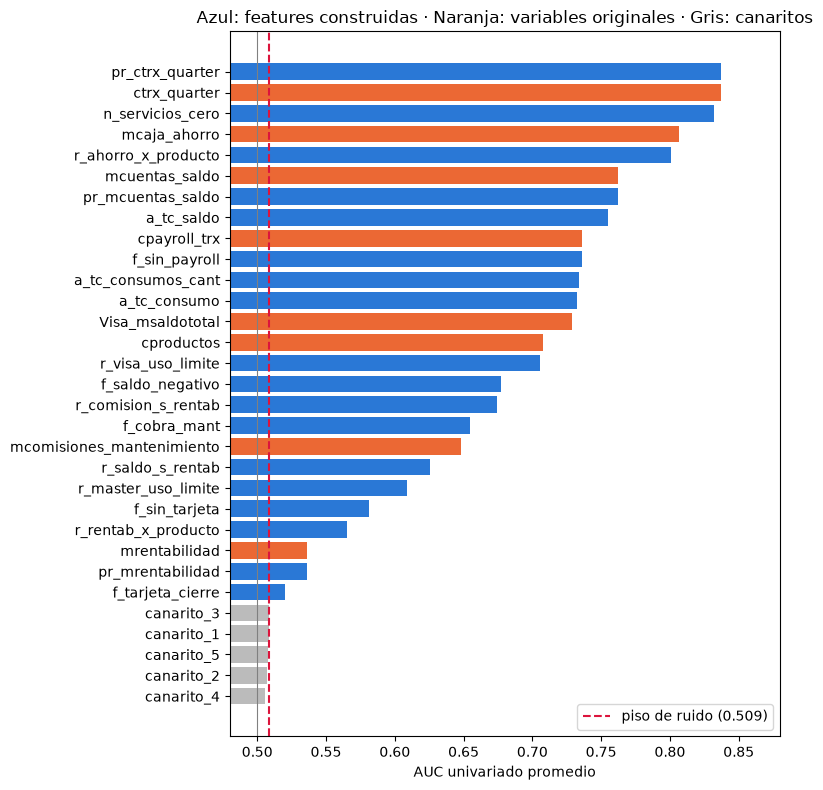

In [ ]:
COMPARACIONES = [
    ("n_servicios_cero",    "ctrx_quarter"),
    ("r_ahorro_x_producto", "mcaja_ahorro"),
    ("a_tc_saldo",          "Visa_msaldototal"),
    ("r_visa_uso_limite",   "Visa_msaldototal"),
    ("f_sin_payroll",       "cpayroll_trx"),
    ("f_saldo_negativo",    "mcuentas_saldo"),
    ("r_saldo_s_rentab",    "mcuentas_saldo"),
    ("r_comision_s_rentab", "mcomisiones_mantenimiento"),
    ("f_cobra_mant",        "mcomisiones_mantenimiento"),
    ("r_rentab_x_producto", "mrentabilidad"),
]

comp = pd.DataFrame([
    {"feature_nueva": nu, "auc_nueva": evaluacion.loc[nu, "auc_prom"],
     "origen": ba, "auc_origen": evaluacion.loc[ba, "auc_prom"],
     "gana": evaluacion.loc[nu, "auc_prom"] > evaluacion.loc[ba, "auc_prom"]}
    for nu, ba in COMPARACIONES
]).round(4)
print(f"ganan a su origen: {comp.gana.sum()} de {len(comp)}")
display(comp)

fig, ax = plt.subplots(figsize=(8, 8))
e = evaluacion.sort_values("auc_prom")
colores = ["#bbbbbb" if i.startswith("canarito") else
           "#2a78d6" if i.startswith(("f_", "r_", "a_", "n_", "pr_")) else "#eb6834"
           for i in e.index]
ax.barh(e.index, e.auc_prom, color=colores)
ax.axvline(piso_ruido, ls="--", color="crimson", label=f"piso de ruido ({piso_ruido:.3f})")
ax.axvline(0.5, color="grey", lw=0.8)
ax.set_xlim(0.48, 0.88)
ax.set_xlabel("AUC univariado promedio")
ax.set_title("Azul: features construidas · Naranja: variables originales · Gris: canaritos")
ax.legend()
plt.tight_layout()

In [ ]:
# Verificación de que percent_rank no cambia el AUC
_m = q("""SELECT clase_ternaria, ctrx_quarter,
                 percent_rank() OVER (ORDER BY ctrx_quarter) AS pr
          FROM c01 WHERE foto_mes = 202104""")
_pos = (_m.clase_ternaria == "BAJA+2").to_numpy().astype(int)
print(f"AUC ctrx_quarter          : {auc_univariado(_m.ctrx_quarter, _pos):.6f}")
print(f"AUC percent_rank(ctrx_q.) : {auc_univariado(_m.pr, _pos):.6f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

AUC ctrx_quarter          : 0.143470
AUC percent_rank(ctrx_q.) : 0.143470
Idénticos: el AUC mira el orden, y percent_rank no reordena a nadie.


In [ ]:
BASE_PR = ["ctrx_quarter", "mcuentas_saldo", "mcaja_ahorro", "mrentabilidad",
           "mpasivos_margen", "mpayroll", "Visa_msaldototal", "mcomisiones_mantenimiento"]
pr_sql = ", ".join(f"percent_rank() OVER (PARTITION BY foto_mes ORDER BY {v}) AS pr_{v}"
                   for v in BASE_PR)
dpr = q(f"SELECT foto_mes, clase_ternaria, {', '.join(BASE_PR)}, {pr_sql} "
        f"FROM c01 WHERE foto_mes <= 202106")


def transferencia(cols, mes_tr, mes_te, etiqueta):
    tr, te = dpr[dpr.foto_mes == mes_tr], dpr[dpr.foto_mes == mes_te]
    ytr = (tr.clase_ternaria == "BAJA+2").astype(int)
    yte = (te.clase_ternaria == "BAJA+2").astype(int).to_numpy()
    m = DecisionTreeClassifier(random_state=SEMILLA, max_depth=5,
                               min_samples_split=80).fit(tr[cols], ytr)
    p = m.predict_proba(te[cols])[:, 1]
    return {"train": mes_tr, "test": mes_te, "variables": etiqueta,
            "AUC_futuro": round(roc_auc_score(yte, p), 4),
            "ganancia_futuro": int(np.where(p >= umbral_negocio,
                                            np.where(yte == 1, ganancia_acierto, -costo_estimulo), 0).sum())}


filas = []
for mes_tr, mes_te in [(202103, 202105), (202104, 202106), (202103, 202106)]:
    filas.append(transferencia(BASE_PR, mes_tr, mes_te, "crudas (pesos)"))
    filas.append(transferencia([f"pr_{v}" for v in BASE_PR], mes_tr, mes_te, "percent_rank intra-mes"))
pd.DataFrame(filas)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,train,test,variables,AUC_futuro,ganancia_futuro
0,202103,202105,crudas (pesos),0.8509,163460000
1,202103,202105,percent_rank intra-mes,0.8492,156777500
2,202104,202106,crudas (pesos),0.8587,298320000
3,202104,202106,percent_rank intra-mes,0.8572,288392500
4,202103,202106,crudas (pesos),0.8672,328570000
5,202103,202106,percent_rank intra-mes,0.8717,325490000


### Conclusiones

**La mejor feature construida parece ser `n_servicios_cero`** (AUC 0,8323): cuántos de seis
servicios el cliente tiene en cero ese mes. Casi iguala a `ctrx_quarter` (0,8374), la
mejor variable del dataset, y **es más estable**.

**Solo 4 de 13 features le ganan a su variable de origen.** Los ratios en
particular fracasan.

**`pr_ctrx_quarter` y `ctrx_quarter` dan 0,8374 las dos, con idéntico mínimo y amplitud.** 
`percent_rank` es una transformación monótona dentro del mes, y el AUC se calcula sobre rangos: 
no cambia el orden, no cambia el AUC.

*Aclaración*: las diferencias están dentro del ruido de medición (un árbol, una semilla, tres particiones).

> **Combinar variables parece ser más útil que transformar.**

Las cuatro que ganaron combinan fuentes distintas: `n_servicios_cero` cruza seis
variables, `a_tc_saldo` suma las dos tarjetas, `r_comision_s_rentab` relaciona dos
conceptos. Las que perdieron son reescalados o divisiones de una variable por otra que
ya estaba en el modelo.

### Lift ≠ AUC

`f_tarjeta_cierre` da **AUC 0,5204, apenas encima del piso de ruido**, pese a que en la
sección 8 `Master_status = 6` mostraba un lift de **31,9×**. Ambas cosas son ciertas: el
lift es enorme sobre 565 clientes de 163.284.